<a href="https://colab.research.google.com/github/Nyymerria/carisurg-portfolio/blob/main/Assignment_3_DataVisualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## SECTION 1: Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print('Libraries imported!')

Libraries imported!


In [4]:
# Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

FILE_PATH ='/content/EmergencyTriageDataset_Reduced_Dirty.csv'
df = pd.read_csv(FILE_PATH)

print(f'Loaded: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded: 2205 rows x 11 columns


,ID,Age,Gender,GCS,SBP,DBP,MAP,pulse,Temp,RR,Fio2
0,1,34,0,15.0,93,67.0,75.67,128.0,36.8,14.0,21.0
1,2,20,Male,15.0,130,90.0,103.33,80.0,37.0,16.0,21.0
2,3,77,Female,14.0,163,105.0,124.33,92.0,36.8,18.0,21.0
3,4,23,0,8.0,100,60.0,73.33,100.0,37.0,12.0,100.0
4,5,86,FEMALE,15.0,150,90.0,110.00,85.0,37.0,19.0,21.0


## SECTION 2: Data Cleaning

In [10]:
# Gender
gender_map = {'Male': 1, 'MALE': 1, '1': 1, 'Female': 0, 'FEMALE': 0, '0': 0}
df['Gender'] = df['Gender'].map(gender_map)

# GCS
df['GCS'] = pd.to_numeric(df['GCS'], errors='coerce')
df.loc[(df['GCS'] < 3) | (df['GCS'] > 15), 'GCS'] = np.nan
df['GCS'] = df['GCS'].fillna(df['GCS'].median())

# SBP
df['SBP'] = pd.to_numeric(df['SBP'], errors='coerce')
df.loc[(df['SBP'] < 50) | (df['SBP'] > 250), 'SBP'] = np.nan
df['SBP'] = df['SBP'].fillna(df['SBP'].median())

# DBP
df['DBP'] = pd.to_numeric(df['DBP'], errors='coerce')
df.loc[(df['DBP'] < 30) | (df['DBP'] > 150), 'DBP'] = np.nan
df['DBP'] = df['DBP'].fillna(df['DBP'].median())

# Pulse
df['pulse'] = pd.to_numeric(df['pulse'], errors='coerce')
df.loc[(df['pulse'] < 20) | (df['pulse'] > 250), 'pulse'] = np.nan
df['pulse'] = df['pulse'].fillna(df['pulse'].median())

# Temp
def to_celsius(val):
    if pd.isnull(val): return np.nan
    s = str(val).strip()
    try:
        if s.endswith('C'): return float(s[:-1])
        elif s.endswith('F'): return (float(s[:-1]) - 32) * 5/9
        else: return float(s)
    except: return np.nan

df['Temp'] = df['Temp'].apply(to_celsius)
df.loc[(df['Temp'] < 32) | (df['Temp'] > 43), 'Temp'] = np.nan
df['Temp'] = df['Temp'].fillna(df['Temp'].median())

# RR
df['RR'] = pd.to_numeric(df['RR'], errors='coerce')
df.loc[(df['RR'] < 5) | (df['RR'] > 60), 'RR'] = np.nan
df['RR'] = df['RR'].fillna(df['RR'].median())

# FiO2
df['Fio2'] = pd.to_numeric(df['Fio2'], errors='coerce')
df['Fio2'] = df['Fio2'].fillna(df['Fio2'].median())  # 100% is clinically valid — no range filter

# MAP
df['MAP'] = pd.to_numeric(df['MAP'], errors='coerce')
df['MAP_Calc'] = (df['SBP'] + 2 * df['DBP']) / 3
df['MAP'] = df['MAP'].fillna(df['MAP_Calc'])
df = df.drop(columns=['MAP_Calc'])

print(f"Clean dataset: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Total NaNs remaining: {df.isnull().sum().sum()}")
df.head()

Clean dataset: 2205 rows x 11 columns
Total NaNs remaining: 0


,ID,Age,Gender,GCS,SBP,DBP,MAP,pulse,Temp,RR,Fio2
0,1,34,0,15.0,93.0,67.0,75.67,128.0,36.8,14.0,21.0
1,2,20,1,15.0,130.0,90.0,103.33,80.0,37.0,16.0,21.0
2,3,77,0,14.0,163.0,105.0,124.33,92.0,36.8,18.0,21.0
3,4,23,0,8.0,100.0,60.0,73.33,100.0,37.0,12.0,100.0
4,5,86,0,15.0,150.0,90.0,110.00,85.0,37.0,19.0,21.0


## SECTION 3: Descriptive Statistics

In [7]:
# Inspect the three columns we are plotting
print('=== FiO2 ===')
print(df['Fio2'].describe().round(2))
print('\nUnique FiO2 values:', sorted(df['Fio2'].unique()))

print('\n=== Pulse ===')
print(df['pulse'].describe().round(2))

print('\n=== MAP ===')
print(df['MAP'].describe().round(2))

=== FiO2 ===
count    2205.00
mean       24.98
std        10.10
min        21.00
25%        21.00
50%        21.00
75%        21.00
max       100.00
Name: Fio2, dtype: float64

Unique FiO2 values: [np.float64(21.0), np.float64(40.0), np.float64(60.0), np.float64(70.0), np.float64(80.0), np.float64(95.0), np.float64(100.0)]

=== Pulse ===
count    2205.00
mean       94.33
std        19.88
min        40.00
25%        80.00
50%        90.00
75%       106.00
max       170.00
Name: pulse, dtype: float64

=== MAP ===
count    2205.00
mean       93.90
std        19.02
min        39.33
25%        82.33
50%        93.33
75%       103.33
max       185.00
Name: MAP, dtype: float64


## SECTION 4: Histogram — FiO2 Distribution

**Clinical question:** Are most ED patients receiving room air, or are they requiring supplemental oxygen?

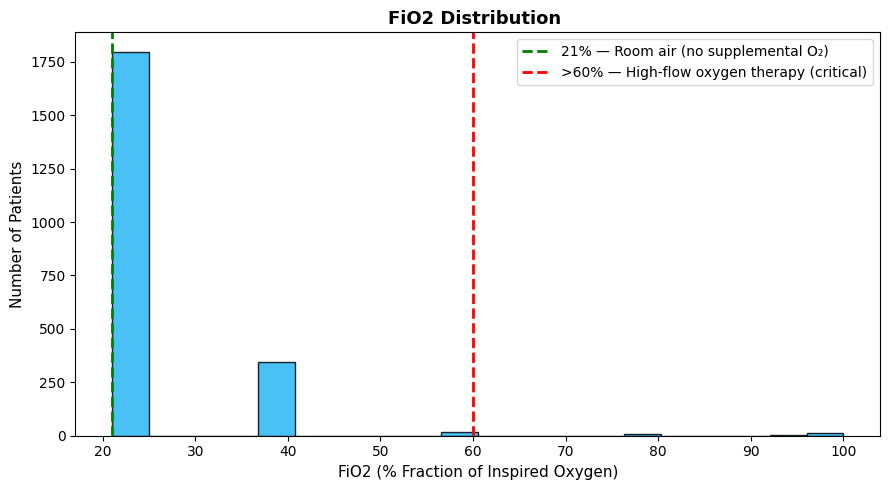

Saved: fio2_histogram.png


In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

# Plot FiO2 histogram
# FiO2 is often stored as a percentage (21% = room air, 100% = pure oxygen)
ax.hist(df['Fio2'], bins=20, edgecolor='black', color='#29B6F6', alpha=0.85)

# Clinical reference line: 21% = room air (no supplemental oxygen)
# Most healthy people breathe air at 21% oxygen
ax.axvline(x=21, color='green', linestyle='--', linewidth=2,
           label='21% — Room air (no supplemental O₂)')

# Clinical reference line: >60% = high-flow oxygen therapy
# This level is typically reserved for critically ill patients
ax.axvline(x=60, color='red', linestyle='--', linewidth=2,
           label='>60% — High-flow oxygen therapy (critical)')

# Labels and title
ax.set_title('FiO2 Distribution ',
             fontsize=13, fontweight='bold')
ax.set_xlabel('FiO2 (% Fraction of Inspired Oxygen)', fontsize=11)
ax.set_ylabel('Number of Patients', fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('fio2_histogram.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: fio2_histogram.png')

Two large spikes,one at 21% (room air, most patients) and one at 40% (standard low-flow supplemental oxygen). Very few patients are above 60%, meaning only a small number are critically ill enough to need high-flow oxygen.

## SECTION 5: Scatter Plot — Pulse vs MAP

**Clinical question:** Do patients with low blood pressure (MAP) compensate with a higher heart rate in the ED?

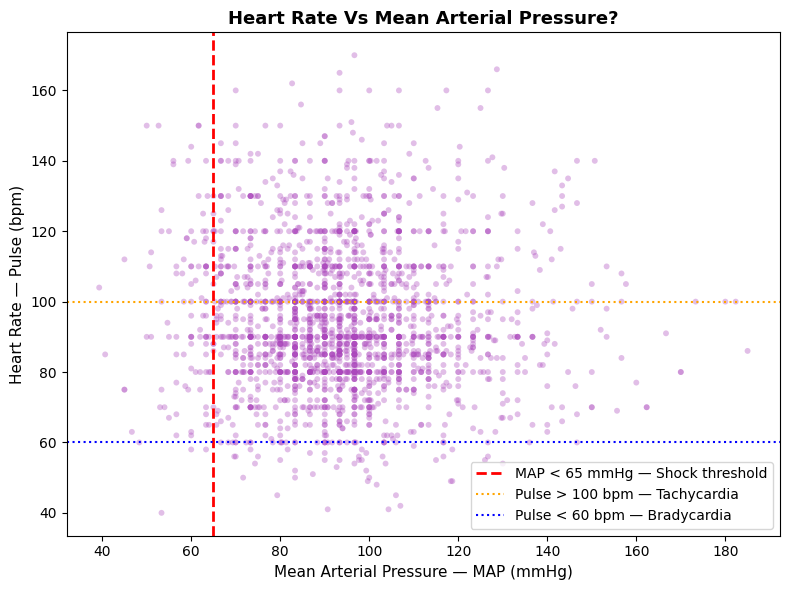

Saved: pulse_vs_map_scatter.png


In [17]:
fig, ax = plt.subplots(figsize=(8, 6))

# We expect an inverse relationship: low MAP → high pulse (the body compensates)
ax.scatter(df['MAP'], df['pulse'],
           alpha=0.35, s=18, color='#AB47BC', edgecolors='none')

# Clinical reference line: MAP < 65 mmHg = shock threshold
# Below this level, organs are at risk of not receiving enough blood flow
ax.axvline(x=65, color='red', linestyle='--', linewidth=2,
           label='MAP < 65 mmHg — Shock threshold')

# Clinical reference lines for pulse
# Normal heart rate range is 60-100 bpm
ax.axhline(y=100, color='orange', linestyle=':', linewidth=1.5,
           label='Pulse > 100 bpm — Tachycardia')
ax.axhline(y=60, color='blue', linestyle=':', linewidth=1.5,
           label='Pulse < 60 bpm — Bradycardia')

# Labels and title — title is phrased as the clinical question
ax.set_title('Heart Rate Vs Mean Arterial Pressure?',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Arterial Pressure — MAP (mmHg)', fontsize=11)
ax.set_ylabel('Heart Rate — Pulse (bpm)', fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('pulse_vs_map_scatter.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: pulse_vs_map_scatter.png')

Typically, patients coming in with low MAP due to factors such bleeding, dehydration, or sepsis will almost always have a high pulse alongside it. This is because the body is actively trying to compensate. However,this tells plot does not show a strong relationship between MAPS and pulse in this dataset, likely because acute illness,stress and pain in the ED drive heart rate more than blood pressure does.

## SECTION 5: Scatter Plot — SBP vs MAP

**Clinical question:** Does systolic blood pressure predict mean arterial pressure in ED patients?

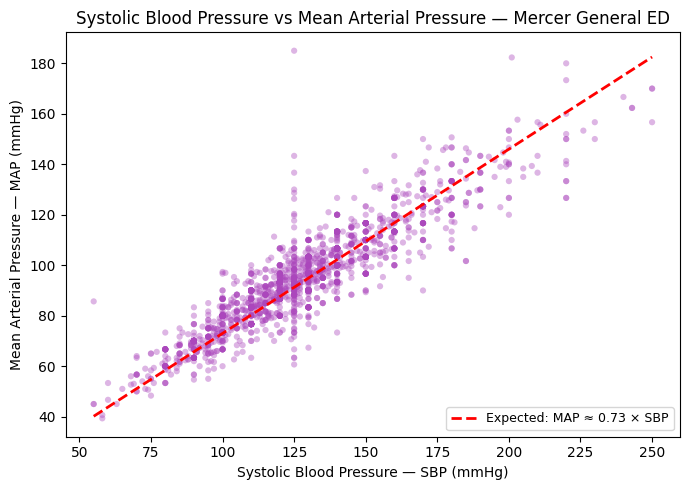

Saved: sbp_vs_map.png


In [16]:


# Scatter plot: SBP vs MAP
fig, ax = plt.subplots(figsize=(7, 5))

# Each dot = one patient
ax.scatter(df['SBP'], df['MAP'],
           alpha=0.4,
           s=20,
           color='#AB47BC',
           edgecolors='none')

# Expected physiological relationship:
# MAP ≈ 0.73 × SBP
sbp_range = np.linspace(df['SBP'].min(), df['SBP'].max(), 100)

ax.plot(sbp_range,
        sbp_range * 0.73,
        color='red',
        linestyle='--',
        linewidth=2,
        label='Expected: MAP ≈ 0.73 × SBP')

# Labels and title
ax.set_title('Systolic Blood Pressure vs Mean Arterial Pressure — Mercer General ED',
             fontsize=12)

ax.set_xlabel('Systolic Blood Pressure — SBP (mmHg)')
ax.set_ylabel('Mean Arterial Pressure — MAP (mmHg)')

# Legend
ax.legend(fontsize=9)

# Layout and save
plt.tight_layout()
plt.savefig('sbp_vs_map.png', dpi=100, bbox_inches='tight')

plt.show()

print("Saved: sbp_vs_map.png")

There's a clear strong diagonal trend ,as SBP goes up, MAP goes up consistently. This makes sense because MAP is mathematically derived from SBP. The red line shows the expected relationship perfectly. Most patients sit safely above the shock threshold.

## SECTION 6: Histogram — Temperature Distribution with Clinical Zones

**Clinical question:** What proportion of ED patients are presenting with hypothermia, normal temperature, fever, or  hyperpyrexia?

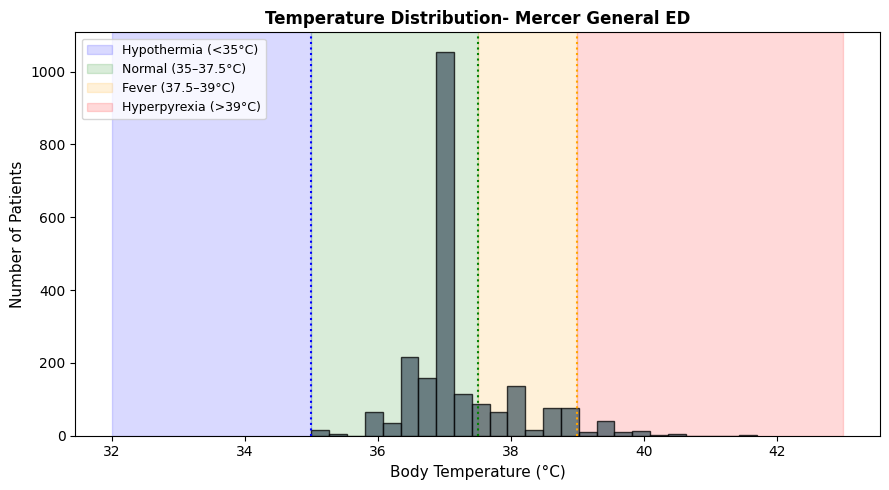

Saved: temp_histogram.png


In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

# Shaded clinical zones — these tell the story visually before you even look at the bars
# Hypothermia: below 35°C — body temperature dangerously low
ax.axvspan(32, 35, alpha=0.15, color='blue', label='Hypothermia (<35°C)')

# Normal range: 35-37.5°C
ax.axvspan(35, 37.5, alpha=0.15, color='green', label='Normal (35–37.5°C)')

# Fever: 37.5-39°C — immune response due to an infection likely
ax.axvspan(37.5, 39, alpha=0.15, color='orange', label='Fever (37.5–39°C)')

# Hyperpyrexia: above 39°C — dangerous, can cause organ damage
ax.axvspan(39, 43, alpha=0.15, color='red', label='Hyperpyrexia (>39°C)')

# Plot the histogram on top of the shaded zones
ax.hist(df['Temp'], bins=25, edgecolor='black', color='#455A64', alpha=0.75)

# Dotted boundary lines so the zone edges are precise
ax.axvline(x=35,   color='blue',   linestyle=':', linewidth=1.5)
ax.axvline(x=37.5, color='green',  linestyle=':', linewidth=1.5)
ax.axvline(x=39,   color='orange', linestyle=':', linewidth=1.5)

# Labels and title
ax.set_title('Temperature Distribution- Mercer General ED',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Body Temperature (°C)', fontsize=11)
ax.set_ylabel('Number of Patients', fontsize=11)
ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('temp_histogram.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: temp_histogram.png')

The vast majority of patients fall in the normal zone (35–37.5°C) with a big spike right at 37°C. A small but notable group are febrile (37.5–39°C) and very few reach hyperpyrexia. Almost nobody is hypothermic.

## SECTION 7: Scatter Plot — Temperature vs Respiratory Rate

**Clinical question:** Does increasing body temperature correlate with faster respiratory rates in emergency department patients?

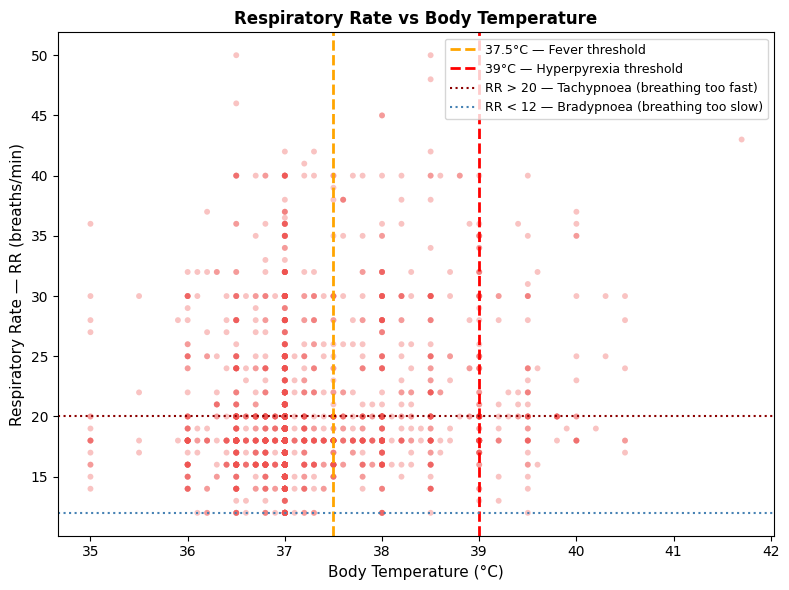

Saved: temp_vs_rr_scatter.png


In [14]:
fig, ax = plt.subplots(figsize=(8, 6))

# We expect an upward trend — higher temp = faster breathing
# Fever makes the body work harder, increasing respiratory rate
ax.scatter(df['Temp'], df['RR'],
           alpha=0.35, s=18, color='#EF5350', edgecolors='none')

# Clinical reference line: 37.5°C = fever threshold
ax.axvline(x=37.5, color='orange', linestyle='--', linewidth=2,
           label='37.5°C — Fever threshold')

# Clinical reference line: 39°C = hyperpyrexia
ax.axvline(x=39, color='red', linestyle='--', linewidth=2,
           label='39°C — Hyperpyrexia threshold')

# Normal respiratory rate range: 12-20 breaths per minute
ax.axhline(y=20, color='darkred', linestyle=':', linewidth=1.5,
           label='RR > 20 — Tachypnoea (breathing too fast)')
ax.axhline(y=12, color='steelblue', linestyle=':', linewidth=1.5,
           label='RR < 12 — Bradypnoea (breathing too slow)')

# Labels and title
ax.set_title('Respiratory Rate vs Body Temperature',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Body Temperature (°C)', fontsize=11)
ax.set_ylabel('Respiratory Rate — RR (breaths/min)', fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('temp_vs_rr_scatter.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: temp_vs_rr_scatter.png')

Based on the graph most patients are clustered between 36–38°C with normal breathing (12–20 breaths/min). There's no strong upward trend, meaning temperature alone doesn't predict respiratory rate in this ED population. The outliers above 20 breaths/min are spread across all temperature ranges. This suggests that other factors like pain or lung conditions drive fast breathing more than fever does.